# Sistema de Recomendação: Vitrine Inteligente (Questão 8)

Neste notebook, construímos um motor de recomendação baseado no comportamento real de compra dos clientes (Filtragem Colaborativa Item-Item). O objetivo é responder à clássica pergunta do e-commerce: *"Quem comprou o GPS Garmin Vortex Maré Drift, também levou o quê?"*

=== SISTEMA DE RECOMENDAÇÃO (Q8.1) ===
Vitrine Base: Quem comprou o 'GPS Garmin Vortex Maré Drift' (ID: 27) também levou...

 ID Produto                Nome do Produto Recomendado Score de Similaridade (Cosseno)
         94           Motor de Popa Volvo Magnum 276HP                          0.8696
         11        GPS Furuno Swift Leviathan Poseidon                          0.8680
         35                         Radar Furuno Swift                          0.8539
          1                Transponder AIS Maré Magnum                          0.8500
        115 Cabo de Nylon Delta Force Magnum Leviathan                          0.8500


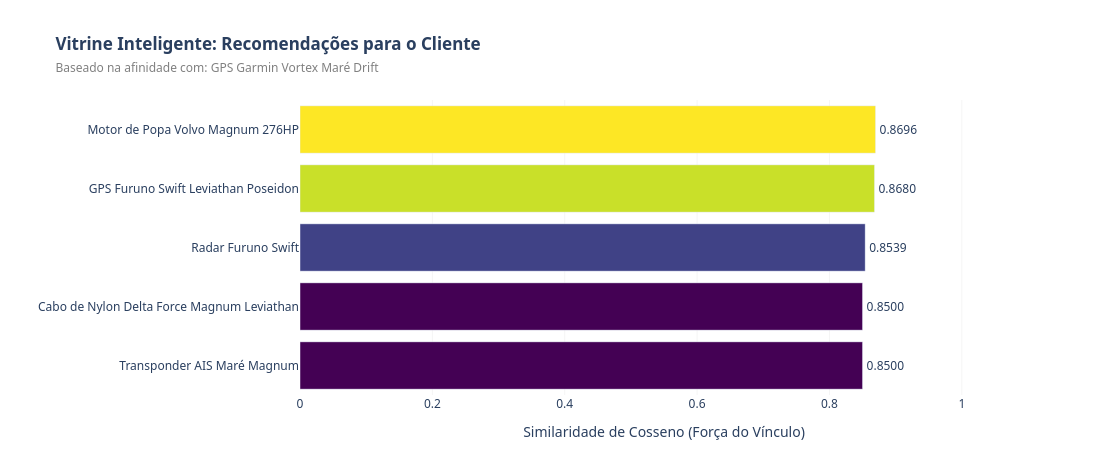

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity

base_path = Path.cwd().parent
sales_file_path = base_path / "data" / "raw" / 'vendas_2023_2024.csv'
products_file_path = base_path / "data" / "raw" / 'produtos_raw.csv' 

df_sales = pd.read_csv(sales_file_path)
df_products = pd.read_csv(products_file_path)

target_product = df_products[df_products["name"].str.contains('GPS Garmin Vortex Maré Drift', case=False, na=False)]

if target_product.empty:
    raise ValueError("Produto alvo não encontrado na base de dados!")
    
target_id = target_product['code'].iloc[0]
target_name = target_product["name"].iloc[0]

user_item_matrix = pd.crosstab(df_sales['id_client'], df_sales['id_product'])
user_item_matrix = (user_item_matrix > 0).astype(int)

item_item_sim_matrix = cosine_similarity(user_item_matrix.T)

df_similarity = pd.DataFrame(
    item_item_sim_matrix, 
    index=user_item_matrix.columns, 
    columns=user_item_matrix.columns
)

similar_scores = df_similarity[target_id].drop(target_id)

top_5_similar = similar_scores.sort_values(ascending=False).head(5).reset_index()
top_5_similar.columns = ['id_product', 'cosine_similarity']

top_5_df = top_5_similar.merge(
    df_products[['code', "name"]], 
    left_on='id_product', 
    right_on='code', 
    how='left'
)

print("=== SISTEMA DE RECOMENDAÇÃO (Q8.1) ===")
print(f"Vitrine Base: Quem comprou o '{target_name}' (ID: {target_id}) também levou...\n")

df_presentation = top_5_df[['id_product', "name", 'cosine_similarity']].copy()
df_presentation.rename(columns={
    'id_product': 'ID Produto',
    "name": 'Nome do Produto Recomendado',
    'cosine_similarity': 'Score de Similaridade (Cosseno)'
}, inplace=True)

df_presentation['Score de Similaridade (Cosseno)'] = df_presentation['Score de Similaridade (Cosseno)'].apply(lambda x: f"{x:.4f}")

print(df_presentation.to_string(index=False))
print("======================================")

# ==========================================
# VISUALIZATION
# ==========================================

import plotly.graph_objects as go

df_plot_sim = top_5_df.sort_values(by='cosine_similarity', ascending=True)

fig_rec = go.Figure()

fig_rec.add_trace(go.Bar(
    y=df_plot_sim["name"],
    x=df_plot_sim['cosine_similarity'],
    orientation='h',
    marker=dict(
        color=df_plot_sim['cosine_similarity'],
        colorscale='Viridis',
        showscale=False
    ),
    text=df_plot_sim['cosine_similarity'],
    texttemplate='%{text:.4f}',
    textposition='outside',
    hovertemplate="<b>%{y}</b><br>Score de Afinidade: %{x:.4f}<extra></extra>"
))

fig_rec.update_layout(
    title=f"<b>Vitrine Inteligente: Recomendações para o Cliente</b><br>" +
          f"<span style='font-size:12px; color:gray;'>Baseado na afinidade com: {target_name}</span>",
    plot_bgcolor='white',
    height=450,
    margin=dict(t=100, l=20, r=80, b=40),
    xaxis=dict(
        title="Similaridade de Cosseno (Força do Vínculo)",
        range=[0, 1.1],
        showgrid=True,
        gridcolor='whitesmoke'
    ),
    yaxis=dict(title="")
)

fig_rec.show()

### Questão 8.2 - Validação

**Qual é o id_produto com MAIOR similaridade ao “GPS Garmin Vortex Maré Drift”?**

94 (Motor de Popa Volvo Magnum 276HP)

### Questão 8.3 -Explique:

**Como a matriz foi construída?**

Através de uma Matriz Usuário x Item cruzando clientes e produtos. Aplicou-se uma binarização estrita: qualquer volume de compra virou `1` (presença/interação) e a falta de compra virou `0`. O foco do modelo é puramente a intenção e a composição do carrinho, ignorando o volume bruto.

**O que significa a Similaridade de Cosseno neste contexto?**
    
Mede a afinidade. Avalia a sobreposição de clientes entre dois itens. Um score elevado indica que os produtos partilham fortemente o mesmo público comprador, sendo os candidatos ideais para ofertas de "compre junto".

**Uma limitação do método:**
    
Por depender exclusivamente de interações passadas, é matematicamente incapaz de recomendar produtos recém-lançados (sem histórico de vendas, efeito cold-start) e tende a gerar um viés de popularidade, recomendando quase sempre os itens mais vendidos (bestsellers) da loja.